In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 103M/103M [00:00<00:00, 160MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1


In [2]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Correctly identify the base path for the dataset content
dataset_base_path = os.path.join(path, 'Car-Bike-Dataset')

# Check if 'Car-Bike-Dataset' exists and list its contents
if os.path.exists(dataset_base_path):
    print(f"\nContents of the '{os.path.basename(dataset_base_path)}' directory ({dataset_base_path}):\n{os.listdir(dataset_base_path)}")
    # Further checks can be added here if needed, e.g., for 'Train' and 'Test' subdirectories
else:
    print(f"\n'Car-Bike-Dataset' directory not found at {dataset_base_path}. Please verify the dataset structure.")


Contents of the dataset directory (/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1):
['Car-Bike-Dataset']

Contents of the 'Car-Bike-Dataset' directory (/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset):
['Car', 'Bike']


In [3]:
import os
from sklearn.model_selection import train_test_split

# Define the base path to the dataset, which was identified in the previous cell
# dataset_base_path is '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset'

# Initialize lists to store image paths and labels
all_image_paths = []
all_image_labels = []

# Iterate through each category (Car, Bike)
for category in ['Car', 'Bike']:
    category_path = os.path.join(dataset_base_path, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(category_path, img_name))
            all_image_labels.append(category)

print(f"Total images found: {len(all_image_paths)}")
print(f"Example image path: {all_image_paths[0] if all_image_paths else 'N/A'}")
print(f"Example image label: {all_image_labels[0] if all_image_labels else 'N/A'}")

Total images found: 3996
Example image path: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset/Car/Car (936).jpeg
Example image label: Car


In [4]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, random_state=42, stratify=all_image_labels
)

print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print("Dataset split successfully!")

Number of training images: 3196
Number of testing images: 800
Dataset split successfully!


## GPU Check and Setup

In [5]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus[0].name}")
    # Optionally, configure GPU memory growth
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found. Training will run on CPU.")

GPU found: /physical_device:GPU:0


## MobileNet Model Setup

In [6]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 10

# Convert image paths and labels to a DataFrame for ImageDataGenerator
train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
test_df = pd.DataFrame({'filename': X_test, 'class': y_test})

# Create ImageDataGenerator for training and validation
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Image data generators created.")

Found 3196 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.
Image data generators created.


In [7]:
# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the convolutional base
base_model.trainable = False

# Add a classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1, activation='sigmoid')(x) # Binary classification (Car/Bike)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training

In [8]:
print(f"Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)

print("Training complete!")

Starting training for 10 epochs...
Epoch 1/10
  3/100 ━━━━━━━━━━━━━━━━━━━━ 40s 417ms/step - accuracy: 0.4479 - loss: 0.8317

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 100s 771ms/step - accuracy: 0.6946 - loss: 0.5908 - val_accuracy: 0.8988 - val_loss: 0.3813
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 553ms/step - accuracy: 0.9208 - loss: 0.3140 - val_accuracy: 0.9737 - val_loss: 0.2148
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 553ms/step - accuracy: 0.9537 - loss: 0.2081 - val_accuracy: 0.9837 - val_loss: 0.1442
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 554ms/step - accuracy: 0.9696 - loss: 0.1520 - val_accuracy: 0.9850 - val_loss: 0.1076
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 550ms/step - accuracy: 0.9725 - loss: 0.1306 - val_accuracy: 0.9875 - val_loss: 0.0864
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 589ms/step - accuracy: 0.9753 - loss: 0.1081 - val_accuracy: 0.9887 - val_loss: 0.0717
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 553ms/step - accuracy: 0.9778 - loss: 0.0956 - val_accuracy: 0.9912 - val_loss: 0.0616
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 558ms/step - accuracy: 0.9784 - loss: 0.0843 - va

## Training Results Summary

In [9]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9912 - loss: 0.0437
Test Loss: 0.0437
Test Accuracy: 0.9912


## Training Plots

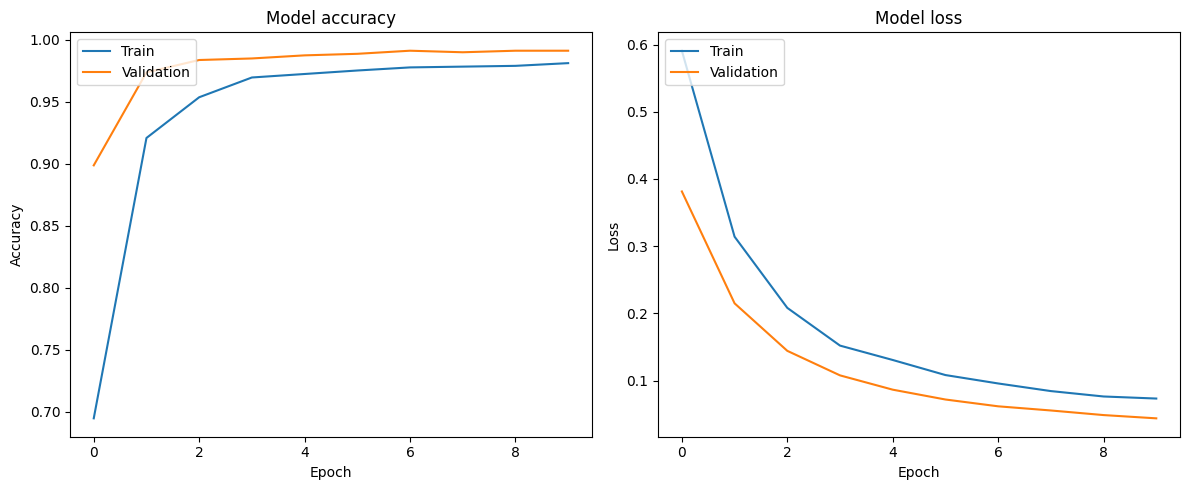

In [10]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()